In [1]:
import torch
import torch.nn as nn
import torchvision.models as models

In [ ]:
BATCH_SIZE = 16
NUM_WORKERS = 0

train_transform, valid_transform = get_pytorch_transforms(img_size=384)

train_dataset = CassavaPyTorchDataset(
    df=train_df,
    img_dir="cassava_data/train_images",
    transform=train_transform
)

valid_dataset = CassavaPyTorchDataset(
    df=val_df,
    img_dir="cassava_data/train_images",
    transform=valid_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    drop_last=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    drop_last=False
)

# 4. Ստուգում (Sanity Check)
images_batch, labels_batch = next(iter(train_loader))

print(f"Batch Images Shape : {images_batch.shape}")
print(f"Batch Labels Shape : {labels_batch.shape}")
print(f"Batch Image Type   : {images_batch.dtype}")
print(f"Batch Label Type   : {labels_batch.dtype}")

Batch Images Shape : torch.Size([16, 3, 384, 384])
Batch Labels Shape : torch.Size([16])
Batch Image Type   : torch.float32
Batch Label Type   : torch.int64


In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix

# Device configuration (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ==========================================
# 1. DESIGN BASELINE CNN ARCHITECTURE
# ==========================================
class BaselineCNN(nn.Module):

  def __init__(self, num_classes=5):
    super(BaselineCNN, self).__init__()

    # Convolutional Block 1
    self.conv1 = nn.Conv2d(
        in_channels=3, out_channels=32, kernel_size=3, padding=1
    )
    self.bn1 = nn.BatchNorm2d(32)
    self.relu1 = nn.ReLU()
    self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # Output: 32 x 112 x 112

    # Convolutional Block 2
    self.conv2 = nn.Conv2d(
        in_channels=32, out_channels=64, kernel_size=3, padding=1
    )
    self.bn2 = nn.BatchNorm2d(64)
    self.relu2 = nn.ReLU()
    self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # Output: 64 x 56 x 56

    # Convolutional Block 3
    self.conv3 = nn.Conv2d(
        in_channels=64, out_channels=128, kernel_size=3, padding=1
    )
    self.bn3 = nn.BatchNorm2d(128)
    self.relu3 = nn.ReLU()
    self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)  # Output: 128 x 28 x 28

    # Fully Connected Classifier
    self.global_pool = nn.AdaptiveAvgPool2d((1, 1))  # Output: 128 x 1 x 1
    self.fc1 = nn.Linear(128, 64)
    self.relu4 = nn.ReLU()
    self.dropout = nn.Dropout(0.3)
    self.fc2 = nn.Linear(64, num_classes)

  def forward(self, x):
    x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
    x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
    x = self.pool3(self.relu3(self.bn3(self.conv3(x))))

    x = self.global_pool(x)
    x = torch.flatten(x, 1)  # Flatten: (batch_size, 128)

    x = self.dropout(self.relu4(self.fc1(x)))
    x = self.fc2(x)
    return x


# Initialize Model, Loss Function, and Optimizer
NUM_CLASSES = 5  # Cassava Leaf Disease classes (0 to 4)
model = BaselineCNN(num_classes=NUM_CLASSES).to(device)

# 1. Standard Loss Function (առանց weights-ի Baseline-ի համար)
criterion = nn.CrossEntropyLoss()

# 2. Optimizer (AdamW + ճշգրտված lr և weight_decay)
optimizer = optim.AdamW(model.parameters(), lr=0.0003, weight_decay=1e-4)

# 3. Learning Rate Scheduler (տատանումները վերացնելու համար)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

Using device: cuda


In [ ]:
import os

# Ստեղծում ենք մոդելների պահպանման թղթապանակը Drive-ում
MODEL_SAVE_DIR = '/content/drive/MyDrive/Cassava_Project/models'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# Լավագույն Baseline մոդելի ֆայլի հասցեն
BASELINE_MODEL_PATH = os.path.join(MODEL_SAVE_DIR, 'baseline_cnn_best.pth')

In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader

# 1. Transform DINOv2-ի համար (224x224)
dinov2_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dinov2_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Թարմացնում ենք Dataset-ների transform-ները
train_dataset.transform = dinov2_train_transform
valid_dataset.transform = dinov2_val_transform

# 3. Ստեղծում ենք DataLoader-ները նոր transform-ով
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

print("✅ DataLoaders updated to 224x224 resolution for DINOv2!")

✅ DataLoaders updated to 224x224 resolution for DINOv2!


In [ ]:
import torch
import torch.nn as nn

class DINOv2Cassava(nn.Module):
    def __init__(self, num_classes=5, freeze_backbone=False):
        super(DINOv2Cassava, self).__init__()
        # Load DINOv2 ViT-Base (vits14 կամ vitb14) PyTorch Hub-ից
        self.backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')

        # Եթե ուզում եք միայն Head-ը սովորեցնել, frozen թողեք backbone-ը
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # DINOv2-vitb14-ի embedding dimension-ը 768 է
        in_features = self.backbone.embed_dim

        # Linear Classifier Head
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # Extract features (cls token representation)
        features = self.backbone(x)
        out = self.classifier(features)
        return out

# Initialize DINOv2 Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_dino = DINOv2Cassava(num_classes=5, freeze_backbone=False).to(device)

print("✅ DINOv2 (ViT-Base) successfully loaded!")

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


✅ DINOv2 (ViT-Base) successfully loaded!


In [ ]:
# DINOv2-ի համար առանձին path Drive-ում
DINO_MODEL_PATH = os.path.join(MODEL_SAVE_DIR, 'dinov2_cassava_best.pth')

In [ ]:
import time
import os
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import DataLoader

# 1. Deadlock-ից խուսափելու համար num_workers=0
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

# 2. Setup Mixed Precision Scaler
scaler = GradScaler()

save_dir = '/content/drive/MyDrive/Cassava_Project'
os.makedirs(save_dir, exist_ok=True)
best_dino_path = os.path.join(save_dir, 'dinov2_vitb14_best.pth')

epochs = 10
best_val_loss = float('inf')

print("🚀 Starting Fast Training with DINOv2 (ViT-Base + FP16)...")

for epoch in range(epochs):
    start_time = time.time()

    # --- TRAINING PHASE ---
    model_dino.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Mixed Precision Forward Pass
        with autocast():
            outputs = model_dino(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        # Gradient Clipping with Scaler
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model_dino.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += torch.sum(preds == labels.data).item()
        train_total += labels.size(0)

    scheduler.step()

    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total

    # --- VALIDATION PHASE ---
    model_dino.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)

            with autocast():
                outputs = model_dino(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data).item()
            val_total += labels.size(0)

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total

    elapsed_time = time.time() - start_time

    print(f"Epoch [{epoch+1}/{epochs}] ({elapsed_time:.1f}s) | "
          f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.4f}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model_dino.state_dict(), best_dino_path)
        print(f"  --> Saved Best Checkpoint (Val Loss: {best_val_loss:.4f})")

/tmp/ipykernel_723/768297421.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


🚀 Starting Fast Training with DINOv2 (ViT-Base + FP16)...


/tmp/ipykernel_723/768297421.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_723/768297421.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/10] (415.2s) | Train Loss: 0.2670 - Train Acc: 0.9180 | Val Loss: 0.4796 - Val Acc: 0.8561
  --> Saved Best Checkpoint (Val Loss: 0.4796)
Epoch [2/10] (416.1s) | Train Loss: 0.2181 - Train Acc: 0.9337 | Val Loss: 0.4344 - Val Acc: 0.8600
  --> Saved Best Checkpoint (Val Loss: 0.4344)
Epoch [3/10] (407.9s) | Train Loss: 0.1633 - Train Acc: 0.9539 | Val Loss: 0.4698 - Val Acc: 0.8703
Epoch [4/10] (404.9s) | Train Loss: 0.1271 - Train Acc: 0.9674 | Val Loss: 0.5180 - Val Acc: 0.8762
Epoch [5/10] (410.8s) | Train Loss: 0.0969 - Train Acc: 0.9772 | Val Loss: 0.5405 - Val Acc: 0.8790
Epoch [6/10] (410.2s) | Train Loss: 0.0797 - Train Acc: 0.9829 | Val Loss: 0.5508 - Val Acc: 0.8764
Epoch [7/10] (406.1s) | Train Loss: 0.0743 - Train Acc: 0.9842 | Val Loss: 0.5556 - Val Acc: 0.8766
Epoch [8/10] (411.8s) | Train Loss: 0.0712 - Train Acc: 0.9844 | Val Loss: 0.5720 - Val Acc: 0.8778
Epoch [9/10] (412.8s) | Train Loss: 0.0685 - Train Acc: 0.9860 | Val Loss: 0.6006 - Val Acc: 0.8778
Epoch 

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


✅ `model_dino`-ն ստեղծվեց և weights-ը հաջողությամբ բեռնվեցին Drive-ից!
Evaluating Best DINOv2 Checkpoint on Validation Set...

--- DINOv2 Classification Report ---
              precision    recall  f1-score   support

         CBB     0.5774    0.6359    0.6053       217
        CBSD     0.8243    0.7283    0.7733       438
         CGM     0.7259    0.7883    0.7558       477
         CMD     0.9599    0.9358    0.9477      2632
     Healthy     0.6754    0.7461    0.7090       516

    accuracy                         0.8600      4280
   macro avg     0.7526    0.7669    0.7582      4280
weighted avg     0.8662    0.8600    0.8623      4280



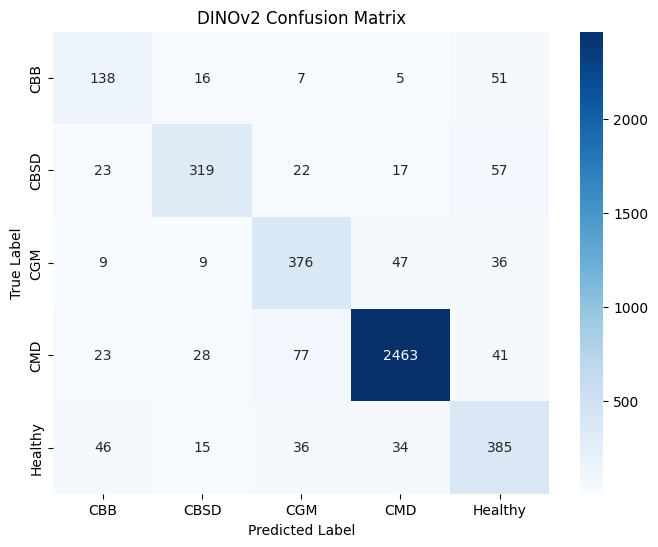

📊 Confusion Matrix-ը պահպանվեց Drive-ում: /content/drive/MyDrive/Cassava_Project/plots/dinov2_confusion_matrix.png


In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# 1. Device Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Սահմանում ենք DINOv2 Architecture-ը (Class-ը)
class DINOv2Cassava(nn.Module):
    def __init__(self, num_classes=5, freeze_backbone=False):
        super(DINOv2Cassava, self).__init__()
        self.backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        in_features = self.backbone.embed_dim

        self.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        out = self.classifier(features)
        return out

# 3. ՍՏԵՂԾՈՒՄ ԵՆՔ model_dino-ն RAM-ՈՒՄ (Սա կվերացնի NameError-ը)
model_dino = DINOv2Cassava(num_classes=5, freeze_backbone=False).to(device)

# 4. Checkpoint-ի ու Plots-ի Path-երը
best_dino_path = '/content/drive/MyDrive/Cassava_Project/dinov2_vitb14_best.pth'
plots_dir = '/content/drive/MyDrive/Cassava_Project/plots'
os.makedirs(plots_dir, exist_ok=True)

# 5. Բեռնում ենք Drive-ի Weight-երը մոդելի մեջ
model_dino.load_state_dict(torch.load(best_dino_path, map_location=device))
model_dino.eval()

print("✅ `model_dino`-ն ստեղծվեց և weights-ը հաջողությամբ բեռնվեցին Drive-ից!")

# -------------------------------------------------------------
# 6. Evaluation Loop (Confusion Matrix & Classification Report)
# -------------------------------------------------------------
all_preds = []
all_labels = []

print("Evaluating Best DINOv2 Checkpoint on Validation Set...")

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        outputs = model_dino(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 7. Classification Report
class_names = ['CBB', 'CBSD', 'CGM', 'CMD', 'Healthy']

print("\n--- DINOv2 Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

# 8. Confusion Matrix Plot
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('DINOv2 Confusion Matrix')

plt.savefig(f'{plots_dir}/dinov2_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"📊 Confusion Matrix-ը պահպանվեց Drive-ում: {plots_dir}/dinov2_confusion_matrix.png")

In [ ]:
# # %%script false skip
# # 2. TRAIN BASELINE MODEL
# # ==========================================
# def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
#   history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

#   for epoch in range(epochs):
#     start_time = time.time()

#     # --- Training Phase ---
#     model.train()
#     running_loss = 0.0
#     correct_train = 0
#     total_train = 0

#     for inputs, labels in train_loader:
#       inputs, labels = inputs.to(device), labels.to(device)

#       optimizer.zero_grad()
#       outputs = model(inputs)
#       loss = criterion(outputs, labels)
#       loss.backward()
#       torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#       optimizer.step()

#       running_loss += loss.item() * inputs.size(0)
#       _, predicted = torch.max(outputs, 1)
#       total_train += labels.size(0)
#       correct_train += (predicted == labels).sum().item()

#     epoch_train_loss = running_loss / total_train
#     epoch_train_acc = correct_train / total_train

#     # --- Validation Phase ---
#     model.eval()
#     val_running_loss = 0.0
#     correct_val = 0
#     total_val = 0

#     with torch.no_grad():
#       for inputs, labels in val_loader:
#         inputs, labels = inputs.to(device), labels.to(device)

#         outputs = model(inputs)
#         loss = criterion(outputs, labels)

#         val_running_loss += loss.item() * inputs.size(0)
#         _, predicted = torch.max(outputs, 1)
#         total_val += labels.size(0)
#         correct_val += (predicted == labels).sum().item()

#     epoch_val_loss = val_running_loss / total_val
#     epoch_val_acc = correct_val / total_val

#     scheduler.step()

#     # Save metrics
#     history["train_loss"].append(epoch_train_loss)
#     history["val_loss"].append(epoch_val_loss)
#     history["train_acc"].append(epoch_train_acc)
#     history["val_acc"].append(epoch_val_acc)

#     elapsed_time = time.time() - start_time
#     print(
#         f"Epoch [{epoch+1}/{epochs}] ({elapsed_time:.1f}s) | "
#         f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.4f} | "
#         f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.4f}"
#     )

#   return history


# # Note: Set epochs according to your needs (e.g., 10-15 for baseline)
# # Ensure train_loader and val_loader are available from your teammate's code.
# history = train_model(
#     model, train_loader, valid_loader, criterion, optimizer, epochs=10
# )

Epoch [1/10] (385.5s) | Train Loss: 1.0339 - Train Acc: 0.6284 | Val Loss: 0.9910 - Val Acc: 0.6458
Epoch [2/10] (367.0s) | Train Loss: 0.9462 - Train Acc: 0.6511 | Val Loss: 0.9016 - Val Acc: 0.6607
Epoch [3/10] (378.3s) | Train Loss: 0.9093 - Train Acc: 0.6632 | Val Loss: 0.8839 - Val Acc: 0.6727
Epoch [4/10] (443.1s) | Train Loss: 0.8770 - Train Acc: 0.6688 | Val Loss: 0.8942 - Val Acc: 0.6680
Epoch [5/10] (345.7s) | Train Loss: 0.8517 - Train Acc: 0.6800 | Val Loss: 0.8156 - Val Acc: 0.6960
Epoch [6/10] (363.8s) | Train Loss: 0.8300 - Train Acc: 0.6879 | Val Loss: 0.8042 - Val Acc: 0.7021
Epoch [7/10] (336.9s) | Train Loss: 0.8155 - Train Acc: 0.6955 | Val Loss: 0.8295 - Val Acc: 0.6960
Epoch [8/10] (338.9s) | Train Loss: 0.7984 - Train Acc: 0.7056 | Val Loss: 0.7765 - Val Acc: 0.7110
Epoch [9/10] (337.0s) | Train Loss: 0.7872 - Train Acc: 0.7052 | Val Loss: 0.7661 - Val Acc: 0.7129
Epoch [10/10] (339.4s) | Train Loss: 0.7838 - Train Acc: 0.7078 | Val Loss: 0.7589 - Val Acc: 0.7157

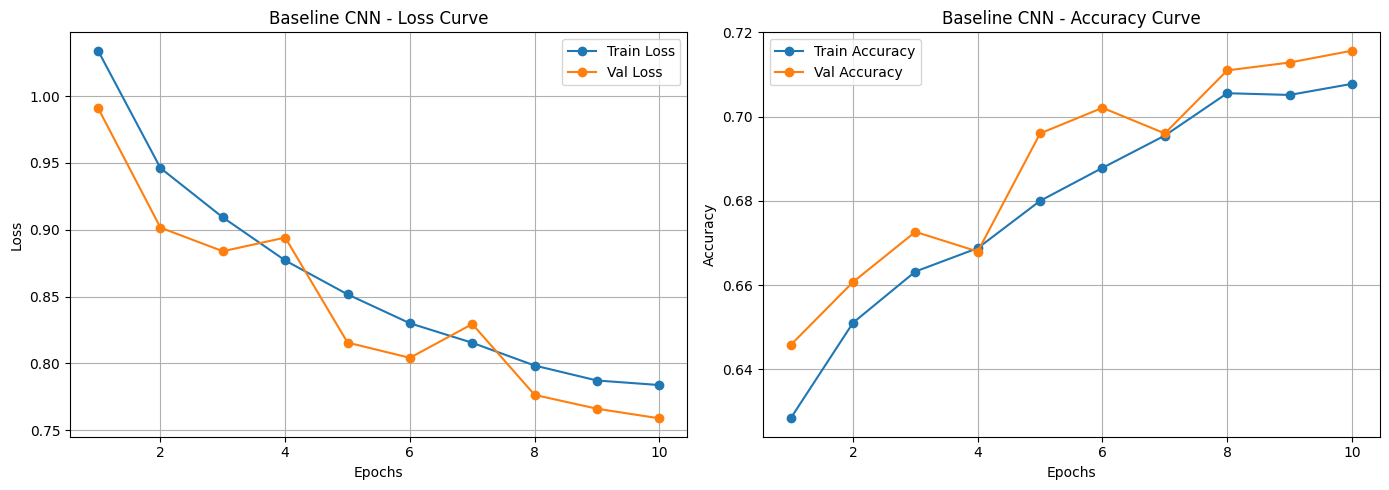

In [ ]:
# # %%script false skip
# # ==========================================
# # 3. BASELINE LEARNING CURVES
# # ==========================================
# def plot_learning_curves(history):
#   epochs = range(1, len(history["train_loss"]) + 1)

#   plt.figure(figsize=(14, 5))

#   # Loss Plot
#   plt.subplot(1, 2, 1)
#   plt.plot(epochs, history["train_loss"], label="Train Loss", marker="o")
#   plt.plot(epochs, history["val_loss"], label="Val Loss", marker="o")
#   plt.title("Baseline CNN - Loss Curve")
#   plt.xlabel("Epochs")
#   plt.ylabel("Loss")
#   plt.legend()
#   plt.grid(True)

#   # Accuracy Plot
#   plt.subplot(1, 2, 2)
#   plt.plot(epochs, history["train_acc"], label="Train Accuracy", marker="o")
#   plt.plot(epochs, history["val_acc"], label="Val Accuracy", marker="o")
#   plt.title("Baseline CNN - Accuracy Curve")
#   plt.xlabel("Epochs")
#   plt.ylabel("Accuracy")
#   plt.legend()
#   plt.grid(True)

#   plt.tight_layout()
#   plt.savefig(
#     f'{plots_dir}/class_distribution.png', dpi=300, bbox_inches='tight'
# )
#   plt.show()


# plot_learning_curves(history)

=== BASELINE CNN CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         CBB       0.37      0.31      0.34       217
        CBSD       0.47      0.30      0.36       438
         CGM       0.62      0.23      0.34       477
         CMD       0.80      0.95      0.87      2632
     Healthy       0.48      0.48      0.48       516

    accuracy                           0.72      4280
   macro avg       0.55      0.46      0.48      4280
weighted avg       0.69      0.72      0.69      4280



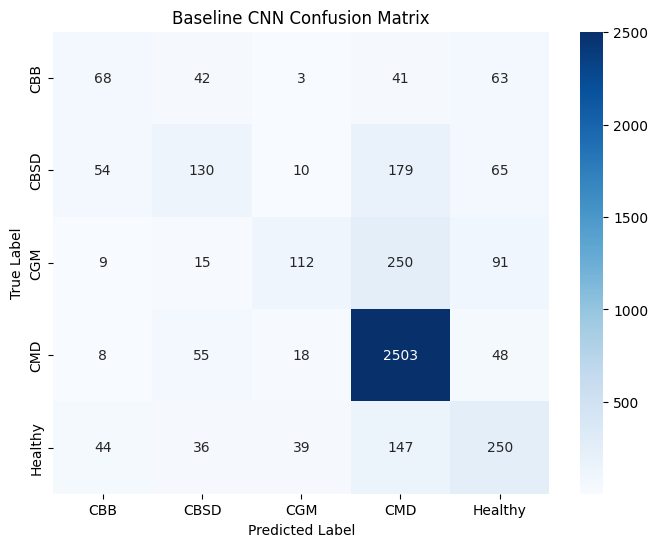

In [ ]:
# %%script false skip
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

class_names = ['CBB', 'CBSD', 'CGM', 'CMD', 'Healthy']
print("=== BASELINE CNN CLASSIFICATION REPORT ===")
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Baseline CNN Confusion Matrix')
plt.savefig(
    f'{plots_dir}/class_distribution.png', dpi=300, bbox_inches='tight'
)
plt.show()

###Pretrained Models
ResNet50

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

MODEL_SAVE_DIR = '/content/drive/MyDrive/Cassava_Project/models'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# Weights-ի ֆայլերի հասցեները
RESNET_PATH = os.path.join(MODEL_SAVE_DIR, 'resnet50_head_best.pth')
EFFNET_PATH = os.path.join(MODEL_SAVE_DIR, 'efficientnet_v2_s_head_best.pth')

def build_resnet50(num_classes=5, freeze_backbone=True):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

def build_efficientnetv2s(num_classes=5, freeze_backbone=True):
    model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model.to(device)

In [ ]:
resnet_model = build_resnet50(num_classes=5, freeze_backbone=True)
effnet_model = build_efficientnetv2s(num_classes=5, freeze_backbone=True)

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 153MB/s]


In [ ]:
def verify_transfer_setup(model, model_name, expected_classes=5):
    model.eval()
    dummy_input = torch.randn(1, 3, 384, 384).to(device)
    with torch.no_grad():
        output = model(dummy_input)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"=== {model_name} ===")
    print(f"Output shape: {output.shape} (պետք է լինի [1, {expected_classes}])")
    print(f"Trainable params: {trainable:,} / {total:,} ({trainable/total*100:.2f}%)")
    assert output.shape[1] == expected_classes, " Output classes-ը սխալ է!"
    print("Setup-ը ճիշտ է\n")

verify_transfer_setup(resnet_model, "ResNet50")
verify_transfer_setup(effnet_model, "EfficientNetV2-S")

=== ResNet50 ===
Output shape: torch.Size([1, 5]) (պետք է լինի [1, 5])
Trainable params: 10,245 / 23,518,277 (0.04%)
Setup-ը ճիշտ է

=== EfficientNetV2-S ===
Output shape: torch.Size([1, 5]) (պետք է լինի [1, 5])
Trainable params: 6,405 / 20,183,893 (0.03%)
Setup-ը ճիշտ է



In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(sorted(train_df['label'].unique())),
    y=train_df['label'].values
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights)

criterion_weighted = nn.CrossEntropyLoss(weight=class_weights)

Class weights: tensor([3.9349, 1.9551, 1.7933, 0.3252, 1.6610], device='cuda:0')


In [ ]:
import time
import torch
from tqdm.notebook import tqdm

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        start_time = time.time()

        # --- Training Phase ---
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        # tqdm progress bar-ը ցույց է տալիս ընթացքը իրական ժամանակում
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

            # Յուրաքանչյուր batch-ից հետո թարմացնում է loss-ը progress bar-ում
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train

        # --- Validation Phase ---
        model.eval()
        val_running_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = val_running_loss / total_val
        epoch_val_acc = correct_val / total_val

        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_acc"].append(epoch_val_acc)

        elapsed_time = time.time() - start_time
        print(
            f"Epoch [{epoch+1}/{epochs}] ({elapsed_time:.1f}s) | "
            f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.4f}"
        )

    return history

print("✅ tqdm-ով `train_model`-ը հաջողությամբ պատրաստ է!")

✅ tqdm-ով `train_model`-ը հաջողությամբ պատրաստ է!


In [ ]:
resnet_optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, resnet_model.parameters()),
    lr=1e-4, weight_decay=1e-4
)

history_resnet_head = train_model(
    resnet_model, train_loader, valid_loader,
    criterion_weighted, resnet_optimizer, epochs=5
)

torch.save(resnet_model.state_dict(), RESNET_PATH)
print(f'✅ ResNet50 weights-ը պահպանվեցին Drive-ում: {RESNET_PATH}\n')

Epoch 1/5 [Train]:   0%|          | 0/1069 [00:00<?, ?it/s]

Epoch [1/5] (449.5s) | Train Loss: 1.3931 - Train Acc: 0.6287 | Val Loss: 1.2642 - Val Acc: 0.6914


Epoch 2/5 [Train]:   0%|          | 0/1069 [00:00<?, ?it/s]

Epoch [2/5] (425.5s) | Train Loss: 1.1916 - Train Acc: 0.6824 | Val Loss: 1.1331 - Val Acc: 0.7016


Epoch 3/5 [Train]:   0%|          | 0/1069 [00:00<?, ?it/s]

Epoch [3/5] (429.9s) | Train Loss: 1.1018 - Train Acc: 0.6936 | Val Loss: 1.0795 - Val Acc: 0.6923


Epoch 4/5 [Train]:   0%|          | 0/1069 [00:00<?, ?it/s]

Epoch [4/5] (425.2s) | Train Loss: 1.0466 - Train Acc: 0.7021 | Val Loss: 1.0279 - Val Acc: 0.6981


Epoch 5/5 [Train]:   0%|          | 0/1069 [00:00<?, ?it/s]

In [ ]:
RESNET_PATH = '/content/drive/MyDrive/Cassava_Project/models/resnet50_head_best.pth'

if os.path.exists(RESNET_PATH):
  resnet_model.load_state_dict(torch.load(RESNET_PATH, map_location=device))
  print(f'✅ ResNet50 head-ի weight-երը հաջողությամբ բեռնվեցին: {RESNET_PATH}')
else:
  print('⚠️ Զգուշացում․ Ֆայլը չգտնվեց, ստուգիր RESNET_PATH հասցեն Drive-ում:')

✅ ResNet50 head-ի weight-երը հաջողությամբ բեռնվեցին: /content/drive/MyDrive/Cassava_Project/models/resnet50_head_best.pth
